In [1]:
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import onnx
import onnxruntime as ort
import pandas as pd

In [2]:
CSV_PATH = r"C:\Users\user\AppData\Roaming\Godot\app_userdata\GodotWebsocketServer\save_2026-01-25_12-37-14-435_cel_hit.csv"

In [3]:
WINDOW_WIDTH = 30

In [4]:
MODEL_PATH: str = "clf_rf.onnx"

In [5]:
labels = np.array(['HIT', 'IDLE', 'SHAKE', 'SWING_LEFT', 'SWING_RIGHT'])

In [6]:
df = pd.read_csv(CSV_PATH)

In [7]:
df.head(5)

,gyro_x,gyro_y,gyro_z,accel_x,accel_y,accel_z,mag_x,mag_y,mag_z,ahrs_x,ahrs_y,ahrs_z,ahrs_w,datetime,gesture
0,-0.002819,-0.037297,-0.031183,-0.636,-8.904,-4.342,47.099998,19.740000,-31.679998,0.397476,-0.472084,0.722889,-0.310775,2026-01-25 12:37:12.699,False
1,-0.002819,-0.037297,-0.031183,-0.636,-8.904,-4.342,46.799999,19.439999,-31.379999,0.397878,-0.472252,0.722540,-0.310816,2026-01-25 12:37:12.717,False
2,-0.009000,-0.046267,-0.030696,-0.714,-8.982,-4.420,46.799999,19.439999,-31.379999,0.398346,-0.472437,0.722136,-0.310876,2026-01-25 12:37:12.734,False
3,-0.009000,-0.046267,-0.030696,-0.714,-8.982,-4.420,46.799999,19.379999,-31.679998,0.398814,-0.472620,0.721732,-0.310936,2026-01-25 12:37:12.751,False
4,-0.009000,-0.046267,-0.030696,-0.714,-8.982,-4.420,46.439999,19.680000,-31.740000,0.399282,-0.472801,0.721327,-0.310999,2026-01-25 12:37:12.767,False


In [8]:
df.describe()

,gyro_x,gyro_y,gyro_z,accel_x,accel_y,accel_z,mag_x,mag_y,mag_z,ahrs_x,ahrs_y,ahrs_z,ahrs_w
count,4370.000000,4370.000000,4370.000000,4370.000000,4370.000000,4370.000000,4370.000000,4370.000000,4370.000000,4370.000000,4370.000000,4370.000000,4370.000000
mean,0.540020,0.042527,-1.122563,-3.369354,-7.928134,-2.648960,17.694260,-7.632769,-19.494892,0.061336,-0.034300,0.035542,0.030507
std,2.329285,1.251526,4.297393,8.480350,15.733205,4.782657,15.106338,15.031266,4.499584,0.565096,0.627824,0.448817,0.279573
min,-11.723509,-6.518767,-13.566756,-38.216000,-38.560001,-32.036999,-2.940000,-39.840000,-47.520000,-0.907592,-0.985035,-0.978067,-0.551824
25%,-0.031888,-0.725029,-3.596964,-3.931000,-17.534000,-3.871000,8.099999,-19.020000,-21.299999,-0.506414,-0.599543,-0.439705,-0.208832
50%,0.381791,-0.054332,-1.411056,-0.243000,-9.610000,-1.988000,12.750000,-13.530000,-19.680000,0.300741,-0.310009,0.118653,-0.037018
75%,1.395877,0.728144,0.162445,1.246000,-2.157000,-0.516750,20.459999,0.465000,-17.879999,0.584339,0.580911,0.455665,0.268169
max,12.443372,11.101904,13.851919,8.072000,37.462002,11.349000,87.720001,54.059998,30.000000,0.926466,0.985174,0.900796,0.703618


In [9]:
len(df)

4370

In [10]:
magnitude = df.filter(regex="^accel_y").values

In [11]:
magnitude = magnitude.flatten()

In [12]:
magnitude.shape

(4370,)

In [13]:
# Simulate or load accelerometer data (x, y, z)
# For example, load from a CSV file:
# data = np.loadtxt('accelerometer_data.csv', delimiter=',')
# x, y, z = data[:, 0], data[:, 1], data[:, 2]

In [14]:
# Simulate some data for demo
# t = np.linspace(0, 10, 1000)
# x = np.sin(t * 5) + np.random.normal(0, 0.1, 1000)
# y = np.cos(t * 5) + np.random.normal(0, 0.1, 1000)
# z = np.sin(t * 5) + np.random.normal(0, 0.1, 1000)

# Calculate magnitude
# magnitude = np.sqrt(x**2 + y**2 + z**2)

In [15]:
# Simple peak detection
# threshold = 36.0  # Adjust based on your data
# peaks = []
# for i in range(0, len(magnitude)-1):
#     if magnitude[i] > threshold and magnitude[i] >= magnitude[i-1] and magnitude[i] >= magnitude[i+1]:
#         peaks.append(i)

In [16]:
from scipy.signal import find_peaks

peaks, _ = find_peaks(magnitude, height=1.2, distance=10)  # Adjust height and distance

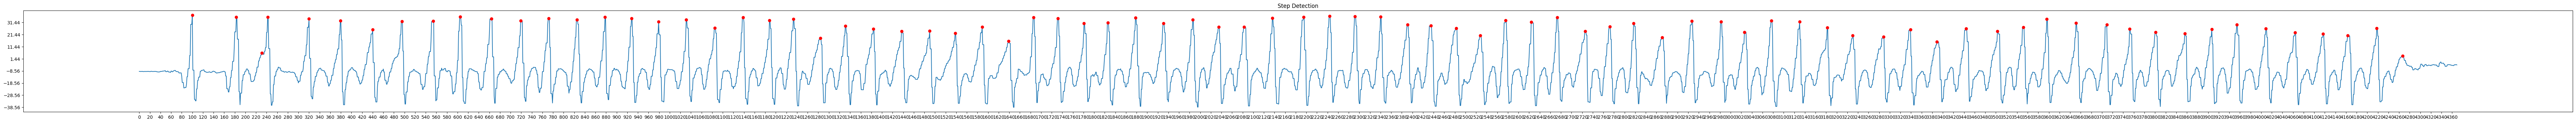

Detected 82 steps


In [17]:
plt.figure(figsize=(100, 4))
plt.plot(magnitude)
plt.plot(peaks, magnitude[peaks], 'ro')
plt.xticks(np.arange(0, len(magnitude)-1, 20))
plt.yticks(np.arange(min(magnitude), max(magnitude), 10))
plt.title('Step Detection')
plt.show()

print(f"Detected {len(peaks)} steps")


In [18]:
def create_windows(df, window_size):
    window = 30
    cols = ["gyro_x", "gyro_y", "gyro_z",
            "accel_x", "accel_y", "accel_z"]
    df_windowed = pd.concat(
        [
            df[cols].shift(-i).add_suffix(f"_{i}")
            for i in range(window)
        ],
        axis=1
    )
    # Drop rows with NaN (incomplete windows at the end)
    df_windowed = df_windowed.dropna().reset_index(drop=True)
    return df_windowed

In [19]:
df_windows = create_windows(df, 30)

In [20]:
df_windows.head(5)

,gyro_x_0,gyro_y_0,gyro_z_0,accel_x_0,accel_y_0,accel_z_0,gyro_x_1,gyro_y_1,gyro_z_1,accel_x_1,...,gyro_z_28,accel_x_28,accel_y_28,accel_z_28,gyro_x_29,gyro_y_29,gyro_z_29,accel_x_29,accel_y_29,accel_z_29
0,-0.002819,-0.037297,-0.031183,-0.636,-8.904,-4.342,-0.002819,-0.037297,-0.031183,-0.636,...,-0.041164,-0.557,-8.982,-4.028,0.057974,-0.036932,-0.045862,-0.636,-8.904,-4.263
1,-0.002819,-0.037297,-0.031183,-0.636,-8.904,-4.342,-0.009000,-0.046267,-0.030696,-0.714,...,-0.045862,-0.636,-8.904,-4.263,0.057974,-0.036932,-0.045862,-0.636,-8.904,-4.263
2,-0.009000,-0.046267,-0.030696,-0.714,-8.982,-4.420,-0.009000,-0.046267,-0.030696,-0.714,...,-0.045862,-0.636,-8.904,-4.263,0.050707,-0.046996,-0.044594,-1.263,-8.982,-4.185
3,-0.009000,-0.046267,-0.030696,-0.714,-8.982,-4.420,-0.009000,-0.046267,-0.030696,-0.714,...,-0.044594,-1.263,-8.982,-4.185,0.050707,-0.046996,-0.044594,-1.263,-8.982,-4.185
4,-0.009000,-0.046267,-0.030696,-0.714,-8.982,-4.420,-0.007273,-0.054286,-0.031048,-0.636,...,-0.044594,-1.263,-8.982,-4.185,0.043235,-0.051084,-0.035429,-1.106,-9.218,-4.969


In [21]:
len(df_windows)

4341

In [22]:
onnx_model: onnx.ModelProto = onnx.load_model(MODEL_PATH)
try:
    onnx.checker.check_model(onnx_model)
    print("Model is valid!")
except Exception as e:
    print(f"Model is invalid: {e}!")

Model is valid!


In [23]:
ort_session = ort.InferenceSession(MODEL_PATH, providers=['CPUExecutionProvider'])

In [24]:
predicted_classes: list[int] = []

for i in range(0, len(df_windows)):
    # attempt to classify
    input_name = ort_session.get_inputs()[0].name
    input_shape = (1, 6 * 29)
    input_data = df_windows.iloc[i].to_numpy(dtype=np.float32).reshape(1, -1)

    ort_inputs = {input_name: input_data}
    
    ort_outputs: list[int] = ort_session.run(None, ort_inputs)
    predicted_classes.append(ort_outputs[0][0])
    print("Model output:", predicted_classes[-1])


Model output: 1
Model output: 1
Model output: 1
Model output: 1
Model output: 1
Model output: 1
Model output: 1
Model output: 1
Model output: 1
Model output: 1
Model output: 1
Model output: 1
Model output: 1
Model output: 1
Model output: 1
Model output: 1
Model output: 1
Model output: 1
Model output: 1
Model output: 1
Model output: 1
Model output: 1
Model output: 1
Model output: 1
Model output: 1
Model output: 1
Model output: 1
Model output: 1
Model output: 1
Model output: 1
Model output: 1
Model output: 1
Model output: 1
Model output: 1
Model output: 1
Model output: 1
Model output: 1
Model output: 1
Model output: 1
Model output: 1
Model output: 1
Model output: 1
Model output: 1
Model output: 1
Model output: 1
Model output: 1
Model output: 1
Model output: 1
Model output: 1
Model output: 1
Model output: 1
Model output: 1
Model output: 1
Model output: 1
Model output: 1
Model output: 1
Model output: 1
Model output: 1
Model output: 1
Model output: 1
Model output: 1
Model output: 1
Model ou

In [25]:
colored = [
    {
        "x": [],
        "y": []
    } for _ in range(len(labels))
]

for i, pc in enumerate(predicted_classes):
    colored[pc]["x"].append(i + WINDOW_WIDTH // 2)
    colored[pc]["y"].append(magnitude[i + WINDOW_WIDTH // 2])

In [26]:
def log_kernel_1d(sigma, size):
    x = np.arange(-size//2 + 1, size//2 + 1)
    kernel = (x**2 - sigma**2) / sigma**4 * np.exp(-x**2 / (2*sigma**2))
    return kernel - np.mean(kernel)  # enforce zero sum

In [27]:
kernel = log_kernel_1d(sigma=2, size=31)

In [28]:
sobel_1d = np.array([-0.5, 0., 0.5])
edge = np.convolve(magnitude, sobel_1d, mode='same')

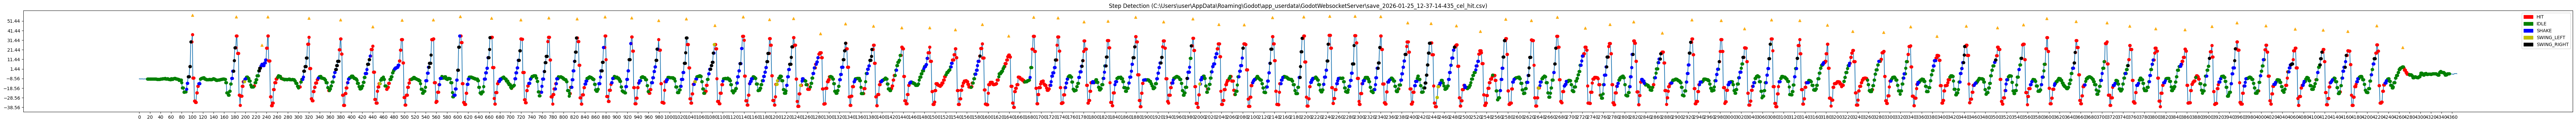

Detected 82 steps


In [29]:
plt.figure(figsize=(100, 4))
plt.plot(magnitude)
plt.plot(peaks, magnitude[peaks] + 20,
    marker='^',
    color='#fcaf17',
    linestyle='None')

plt.plot(colored[0]["x"], colored[0]["y"], 'ro')
plt.plot(colored[1]["x"], colored[1]["y"], 'go')
plt.plot(colored[2]["x"], colored[2]["y"], 'bo')
plt.plot(colored[3]["x"], colored[3]["y"], 'yo')
plt.plot(colored[4]["x"], colored[4]["y"], 'ko')

plt.xticks(np.arange(0, len(magnitude)-1, 20))
plt.yticks(np.arange(min(magnitude), max(magnitude) + 20, 10))

red_patch = mpatches.Patch(color='r', label=labels[0])
green_patch = mpatches.Patch(color='g', label=labels[1])
blue_patch = mpatches.Patch(color='b', label=labels[2])
yellow_patch = mpatches.Patch(color='y', label=labels[3])
key_patch = mpatches.Patch(color='k', label=labels[4])
plt.legend(handles=[red_patch, green_patch, blue_patch, yellow_patch, key_patch])

plt.title(f'Step Detection ({CSV_PATH})')

plt.show()

print(f"Detected {len(peaks)} steps")